In [494]:
 #Part A

In [ ]:
# Similar model architecture as Food-101 model (baseline)

In [862]:
#import of all important libraries required for the project
import copy
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from tqdm.auto import tqdm 
from sklearn.metrics import precision_score, recall_score, f1_score

In [496]:
#setup of GPU for faster acceleration and training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = 101
EPOCHS = 10
LEARNING_RATE = 0.01
MOMENTUM = 0.9
NUM_WORKERS = 0
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [497]:
# Data augmentation same as the paper to keep the model as similar as possible
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

In [498]:
# Data spilitting similar to Food-101 paper
full_train_dataset = datasets.Food101(
    root="./data",
    split="train",
    transform=train_transform,
    download=True
)

test_dataset = datasets.Food101(
    root="./data",
    split="test",
    transform=eval_transform,
    download=True
)

train_size = int(0.9 * len(full_train_dataset))   # 68,175
val_size = len(full_train_dataset) - train_size   # 7,575

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

val_dataset.dataset = copy.deepcopy(full_train_dataset)
val_dataset.dataset.transform = eval_transform

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 68175
Validation size: 7575
Test size: 25250


In [499]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

In [500]:
# laoding the model weights used in the paper for training
model = models.googlenet(weights=models.GoogLeNet_Weights.DEFAULT)

# Disable auxiliary classifiers to simplify training
model.aux_logits = False

# Replace final classifier
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.7),          # paper uses 70% dropout
    nn.Linear(in_features, NUM_CLASSES)
)

model = model.to(device)
print(model)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [501]:
# Setup for optimizer and schedular
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=LEARNING_RATE,
    momentum=MOMENTUM
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [502]:
# Model loss and accuracy calculation
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

        progress_bar.set_postfix(
            loss=running_loss / total,
            acc=running_correct / total
        )

    return running_loss / total, running_correct / total


def evaluate(model, loader, criterion, device, desc="Validation"):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        progress_bar = tqdm(loader, desc=desc, leave=False)

        for images, labels in progress_bar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_correct += (preds == labels).sum().item()
            total += labels.size(0)

            progress_bar.set_postfix(
                loss=running_loss / total,
                acc=running_correct / total
            )

    return running_loss / total, running_correct / total

In [503]:
# Model training
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())
early_stop_patience = 4
early_stop_counter = 0

start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device, desc="Validation")

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        early_stop_counter = 0
        print("Best model updated.")
    else:
        early_stop_counter += 1
        print(f"No improvement: {early_stop_counter}/{early_stop_patience}")

    if early_stop_counter >= early_stop_patience:
        print("Early stopping triggered.")
        break

print(f"\nTraining completed in {(time.time() - start_time)/60:.2f} minutes")


Epoch 1/10


Training:   0%|          | 0/4261 [00:00<?, ?it/s]

Validation:   0%|          | 0/474 [00:00<?, ?it/s]

Train Loss: 2.9636 | Train Acc: 0.2900
Val Loss:   2.2216 | Val Acc:   0.4432
LR: 0.010000
Best model updated.

Epoch 2/10


Training:   0%|          | 0/4261 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/474 [00:00<?, ?it/s]

Train Loss: 1.0078 | Train Acc: 0.7310
Val Loss:   1.3948 | Val Acc:   0.6635
LR: 0.010000
Best model updated.

Epoch 10/10


Training:   0%|          | 0/4261 [00:00<?, ?it/s]

Validation:   0%|          | 0/474 [00:00<?, ?it/s]

Train Loss: 0.9264 | Train Acc: 0.7490
Val Loss:   1.4585 | Val Acc:   0.6536
LR: 0.010000
No improvement: 1/4

Training completed in 114.91 minutes


In [504]:
# Model results
model.load_state_dict(best_model_wts)

test_loss, test_acc = evaluate(model, test_loader, criterion, device, desc="Testing")

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Testing:   0%|          | 0/1579 [00:00<?, ?it/s]


Test Loss: 1.1276
Test Accuracy: 0.7089


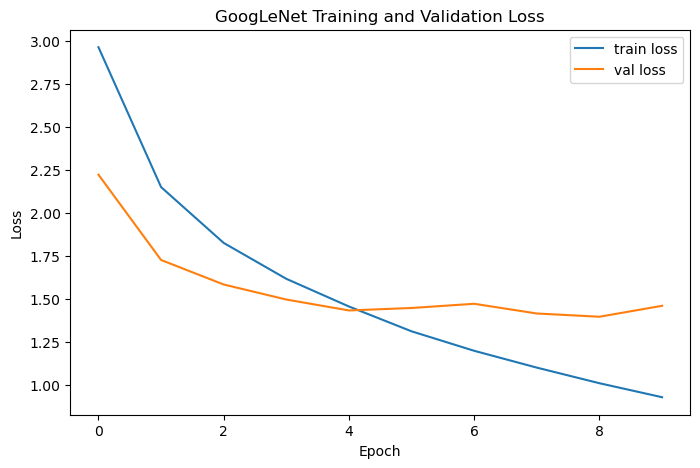

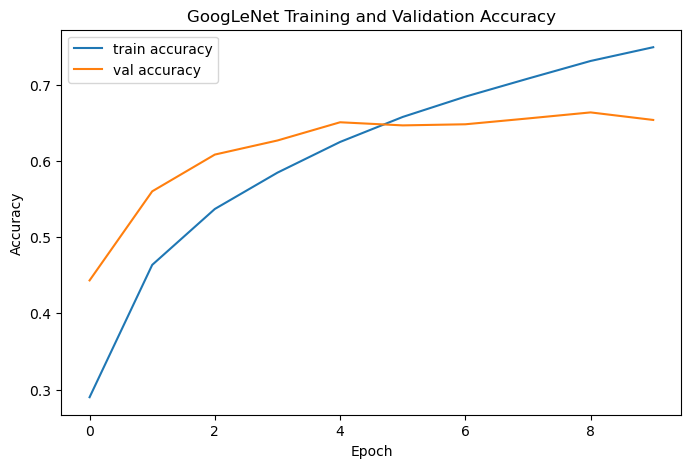

In [505]:
# Graphical representation
plt.figure(figsize=(8,5))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GoogLeNet Training and Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["train_acc"], label="train accuracy")
plt.plot(history["val_acc"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GoogLeNet Training and Validation Accuracy")
plt.legend()
plt.show()

In [506]:
from sklearn.metrics import confusion_matrix
import numpy as np
from tqdm.auto import tqdm

def get_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Collecting predictions", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

In [507]:
# computation for sensitvity, precision, and specificity
def compute_metrics(y_true, y_pred, num_classes=101):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))

    precision_list = []
    sensitivity_list = []  # recall
    specificity_list = []

    for i in range(num_classes):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - (TP + FP + FN)

    
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

        precision_list.append(precision)
        sensitivity_list.append(sensitivity)
        specificity_list.append(specificity)

    return {
        "precision": np.mean(precision_list),
        "sensitivity": np.mean(sensitivity_list),
        "specificity": np.mean(specificity_list)
    }

In [508]:
y_true, y_pred = get_predictions(model, test_loader, device)

metrics = compute_metrics(y_true, y_pred, num_classes=101)

print(f"Precision:   {metrics['precision']:.4f}")
print(f"Sensitivity: {metrics['sensitivity']:.4f}")
print(f"Specificity: {metrics['specificity']:.4f}")

Precision:   0.7221
Sensitivity: 0.7089
Specificity: 0.9971


In [ ]:
# Part b custom CNN model 

In [ ]:
# Computed 3 models - ViT, ResNet50, and EfficientNet-B2
# EfficientNet-B2 performed the best rest models for comparision

In [509]:
#ResNet50

In [510]:
import copy
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models
from tqdm.auto import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score

In [512]:
resnet_weights = models.ResNet50_Weights.DEFAULT
resnet_train_transform = resnet_weights.transforms()
resnet_eval_transform = resnet_weights.transforms()

In [513]:
full_train_dataset = datasets.Food101(
    root="./data",
    split="train",
    transform=resnet_train_transform,
    download=True
)

test_dataset = datasets.Food101(
    root="./data",
    split="test",
    transform=resnet_eval_transform,
    download=True
)

train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

val_dataset.dataset = copy.deepcopy(full_train_dataset)
val_dataset.dataset.transform = resnet_eval_transform

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

In [514]:
resnet_model = models.resnet50(weights=resnet_weights)

# Freeze convolutional backbone
for param in resnet_model.parameters():
    param.requires_grad = False

in_features = resnet_model.fc.in_features
resnet_model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(256, NUM_CLASSES)
)

resnet_model = resnet_model.to(device)
print(resnet_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [515]:
criterion = nn.CrossEntropyLoss()

resnet_optimizer = optim.Adam(resnet_model.fc.parameters(), lr=1e-3)

resnet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    resnet_optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [516]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    pbar = tqdm(loader, desc="Training", leave=False)

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix(loss=running_loss / total, acc=running_correct / total)

    return running_loss / total, running_correct / total


def evaluate(model, loader, criterion, device, desc="Validation"):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc=desc, leave=False)

        for images, labels in pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += labels.size(0)

            pbar.set_postfix(loss=running_loss / total, acc=running_correct / total)

    return running_loss / total, running_correct / total

In [517]:
def fit_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs=8):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_loss = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())
    patience = 4
    counter = 0

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device, desc="Validation")

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            counter = 0
            print("Best model updated.")
        else:
            counter += 1
            print(f"No improvement: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_model_wts)
    return model, history

In [518]:
resnet_model, resnet_history = fit_model(
    resnet_model,
    train_loader,
    val_loader,
    criterion,
    resnet_optimizer,
    resnet_scheduler,
    device,
    epochs=8
)


Epoch 1/8


Training:   0%|          | 0/4261 [00:00<?, ?it/s]

Validation:   0%|          | 0/474 [00:00<?, ?it/s]

Train Loss: 2.9693 | Train Acc: 0.2938
Val Loss:   2.0562 | Val Acc:   0.4986
Best model updated.

Epoch 2/8


Training:   0%|          | 0/4261 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/474 [00:00<?, ?it/s]

Train Loss: 2.4589 | Train Acc: 0.3963
Val Loss:   1.8661 | Val Acc:   0.5407
No improvement: 3/4

Epoch 8/8


Training:   0%|          | 0/4261 [00:00<?, ?it/s]

Validation:   0%|          | 0/474 [00:00<?, ?it/s]

Train Loss: 2.3560 | Train Acc: 0.4186
Val Loss:   1.8403 | Val Acc:   0.5543
Best model updated.


In [519]:
resnet_test_loss, resnet_test_acc = evaluate(resnet_model, test_loader, criterion, device, desc="Testing")

print(f"ResNet50 Test Loss: {resnet_test_loss:.4f}")
print(f"ResNet50 Test Accuracy: {resnet_test_acc:.4f}")

Testing:   0%|          | 0/1579 [00:00<?, ?it/s]

ResNet50 Test Loss: 1.6248
ResNet50 Test Accuracy: 0.5973


In [ ]:
# Vision Transformer ViT

In [520]:
VIT_BATCH_SIZE = 8

In [521]:
vit_weights = models.ViT_B_16_Weights.DEFAULT
vit_train_transform = vit_weights.transforms()
vit_eval_transform = vit_weights.transforms()

In [522]:
vit_full_train_dataset = datasets.Food101(
    root="./data",
    split="train",
    transform=vit_train_transform,
    download=True
)

vit_test_dataset = datasets.Food101(
    root="./data",
    split="test",
    transform=vit_eval_transform,
    download=True
)

vit_train_dataset, vit_val_dataset = random_split(
    vit_full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

vit_val_dataset.dataset = copy.deepcopy(vit_full_train_dataset)
vit_val_dataset.dataset.transform = vit_eval_transform

vit_train_loader = DataLoader(vit_train_dataset, batch_size=VIT_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
vit_val_loader = DataLoader(vit_val_dataset, batch_size=VIT_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
vit_test_loader = DataLoader(vit_test_dataset, batch_size=VIT_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

In [523]:
vit_model = models.vit_b_16(weights=vit_weights)

for param in vit_model.parameters():
    param.requires_grad = False

in_features = vit_model.heads.head.in_features
vit_model.heads.head = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(256, NUM_CLASSES)
)

vit_model = vit_model.to(device)
print(vit_model)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [524]:
vit_optimizer = optim.Adam(
    vit_model.heads.head.parameters(),
    lr=1e-3
)

vit_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    vit_optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [525]:
vit_model, vit_history = fit_model(
    vit_model,
    vit_train_loader,
    vit_val_loader,
    criterion,
    vit_optimizer,
    vit_scheduler,
    device,
    epochs=8
)


Epoch 1/8


Training:   0%|          | 0/8522 [00:00<?, ?it/s]

Validation:   0%|          | 0/947 [00:00<?, ?it/s]

Train Loss: 2.2267 | Train Acc: 0.4397
Val Loss:   1.6202 | Val Acc:   0.5843
Best model updated.

Epoch 2/8


Training:   0%|          | 0/8522 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/947 [00:00<?, ?it/s]

Train Loss: 1.8622 | Train Acc: 0.5369
Val Loss:   1.5056 | Val Acc:   0.6293
No improvement: 1/4

Epoch 8/8


Training:   0%|          | 0/8522 [00:00<?, ?it/s]

Validation:   0%|          | 0/947 [00:00<?, ?it/s]

Train Loss: 1.8420 | Train Acc: 0.5418
Val Loss:   1.4916 | Val Acc:   0.6331
Best model updated.


In [526]:
vit_test_loss, vit_test_acc = evaluate(vit_model, vit_test_loader, criterion, device, desc="Testing")

print(f"ViT Test Loss: {vit_test_loss:.4f}")
print(f"ViT Test Accuracy: {vit_test_acc:.4f}")

Testing:   0%|          | 0/3157 [00:00<?, ?it/s]

ViT Test Loss: 1.2845
ViT Test Accuracy: 0.6815


In [ ]:
# calculation of reuslts for ResNet50 and ViT

In [527]:
def compute_metrics(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Collecting predictions", leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return precision, recall, f1

In [528]:
resnet_precision, resnet_recall, resnet_f1 = compute_metrics(resnet_model, test_loader, device)
print(f"ResNet50 Precision: {resnet_precision:.4f}")
print(f"ResNet50 Recall:    {resnet_recall:.4f}")
print(f"ResNet50 F1:        {resnet_f1:.4f}")

ResNet50 Precision: 0.5946
ResNet50 Recall:    0.5973
ResNet50 F1:        0.5885


In [529]:
vit_precision, vit_recall, vit_f1 = compute_metrics(vit_model, vit_test_loader, device)
print(f"ViT Precision: {vit_precision:.4f}")
print(f"ViT Recall:    {vit_recall:.4f}")
print(f"ViT F1:        {vit_f1:.4f}")

ViT Precision: 0.6916
ViT Recall:    0.6815
ViT F1:        0.6813


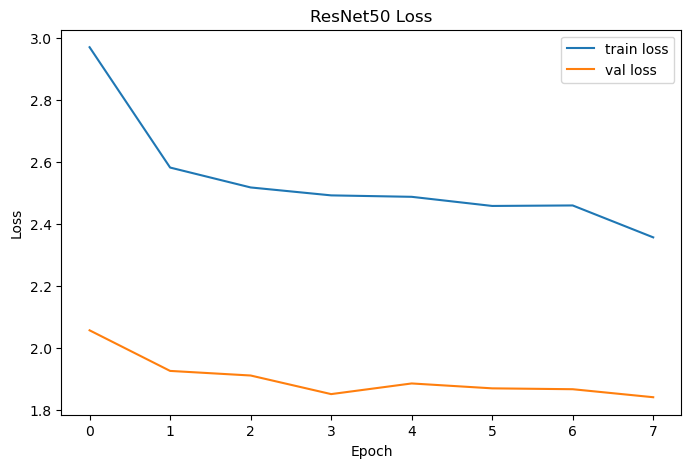

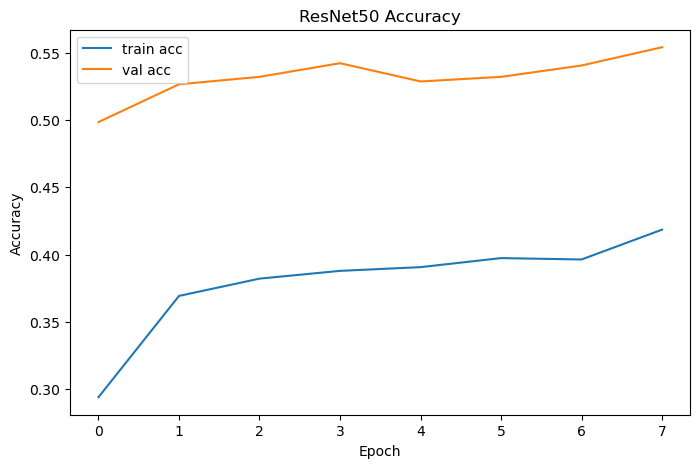

In [530]:
plt.figure(figsize=(8,5))
plt.plot(resnet_history["train_loss"], label="train loss")
plt.plot(resnet_history["val_loss"], label="val loss")
plt.title("ResNet50 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(resnet_history["train_acc"], label="train acc")
plt.plot(resnet_history["val_acc"], label="val acc")
plt.title("ResNet50 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

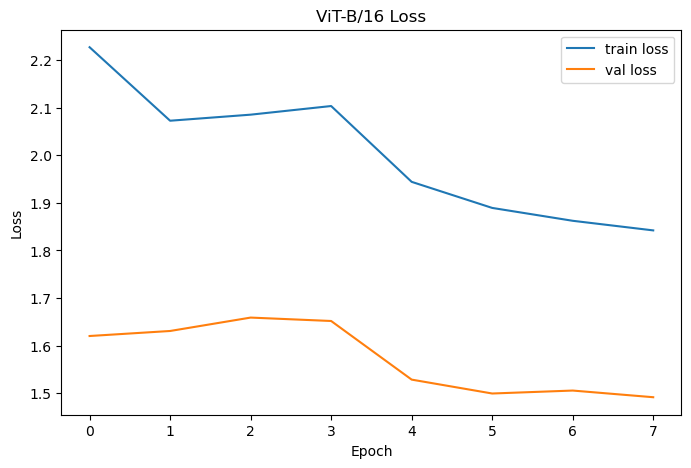

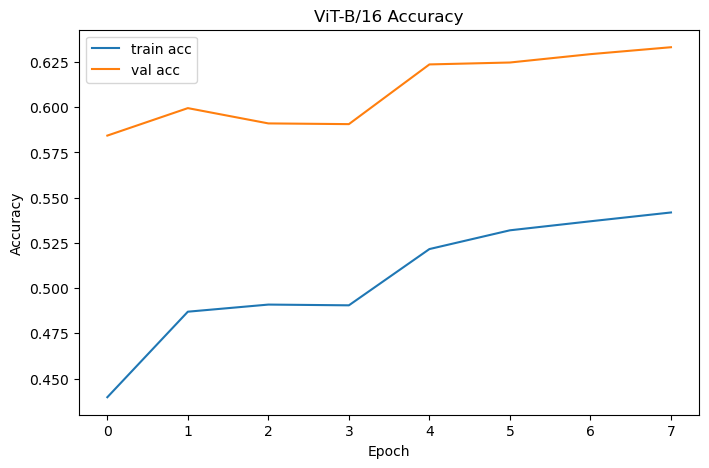

In [531]:
plt.figure(figsize=(8,5))
plt.plot(vit_history["train_loss"], label="train loss")
plt.plot(vit_history["val_loss"], label="val loss")
plt.title("ViT-B/16 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(vit_history["train_acc"], label="train acc")
plt.plot(vit_history["val_acc"], label="val acc")
plt.title("ViT-B/16 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [532]:
#efficient b2 Customm CNN model with additional layers

In [788]:
NUM_CLASSES = 101
BATCH_SIZE = 8
EPOCHS_HEAD = 8
EPOCHS_FINE = 12
LR_HEAD = 1e-3
LR_FINE = 3e-5
NUM_WORKERS = 0

In [789]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)])

In [790]:
weights = models.EfficientNet_B2_Weights.DEFAULT
train_transform = weights.transforms()
test_transform = weights.transforms()

full_train_dataset = datasets.Food101(
    root="./data",
    split="train",
    transform=train_transform,
    download=True
)

test_dataset = datasets.Food101(
    root="./data",
    split="test",
    transform=test_transform,
    download=True
)

train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

val_dataset.dataset = copy.deepcopy(full_train_dataset)
val_dataset.dataset.transform = eval_transform

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

In [ ]:
# model training and updation by adding custom CNN layers

In [791]:
class EfficientNetB2CustomHead(nn.Module):
    def __init__(self, num_classes=101):
        super().__init__()

        base = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)

        # pretrained backbone feature extractor
        self.features = base.features

        # EfficientNet-B2 feature output channels = 1408
        self.custom_conv = nn.Sequential(
            nn.Conv2d(1408, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
            nn.Dropout(0.3)
        )
        

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    def extract_features(self, x):
        x = self.features(x)
        x = self.custom_conv(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return x

    def forward(self, x):
        x = self.features(x)
        x = self.custom_conv(x)
        x = self.classifier(x)
        return x

In [792]:
model = EfficientNetB2CustomHead(num_classes=NUM_CLASSES).to(device)
print(model)

EfficientNetB2CustomHead(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2

In [793]:
for param in model.features.parameters():
    param.requires_grad = False

for param in model.custom_conv.parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

In [794]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    list(model.custom_conv.parameters()) + list(model.classifier.parameters()),
    lr=LR_HEAD
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [795]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    pbar = tqdm(loader, desc="Training", leave=False)

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix(loss=running_loss / total, acc=running_correct / total)

    return running_loss / total, running_correct / total


def evaluate(model, loader, criterion, device, desc="Validation"):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc=desc, leave=False)

        for images, labels in pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += labels.size(0)

            pbar.set_postfix(loss=running_loss / total, acc=running_correct / total)

    return running_loss / total, running_correct / total

In [796]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())
patience = 4
counter = 0

for epoch in range(EPOCHS_HEAD):
    print(f"\nHead Training Epoch {epoch+1}/{EPOCHS_HEAD}")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device, desc="Validation")

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0
        print("Best model updated.")
    else:
        counter += 1
        print(f"No improvement: {counter}/{patience}")

    if counter >= patience:
        print("Early stopping triggered.")
        break


Head Training Epoch 1/8


Training:   0%|          | 0/8522 [00:00<?, ?it/s]

Validation:   0%|          | 0/947 [00:00<?, ?it/s]

Train Loss: 3.4839 | Train Acc: 0.1723
Val Loss:   2.7041 | Val Acc:   0.3331
Best model updated.

Head Training Epoch 2/8


Training:   0%|          | 0/8522 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/947 [00:00<?, ?it/s]

Train Loss: 1.9312 | Train Acc: 0.5172
Val Loss:   2.0690 | Val Acc:   0.5083
No improvement: 1/4

Head Training Epoch 8/8


Training:   0%|          | 0/8522 [00:00<?, ?it/s]

Validation:   0%|          | 0/947 [00:00<?, ?it/s]

Train Loss: 1.8549 | Train Acc: 0.5353
Val Loss:   2.0386 | Val Acc:   0.5138
Best model updated.


In [797]:
model.load_state_dict(best_model_wts)

for name, param in model.features.named_parameters():
    # unfreezing later EfficientNet blocks
    if "6" in name or "7" in name or "8" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

for param in model.custom_conv.parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_FINE
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

best_val_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())
counter = 0

for epoch in range(EPOCHS_FINE):
    print(f"\nFine-Tuning Epoch {epoch+1}/{EPOCHS_FINE}")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device, desc="Validation")

    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0
        print("Best model updated.")
    else:
        counter += 1
        print(f"No improvement: {counter}/3")

    if counter >= 3:
        print("Early stopping triggered.")
        break


Fine-Tuning Epoch 1/12


Training:   0%|          | 0/8522 [00:00<?, ?it/s]

Validation:   0%|          | 0/947 [00:00<?, ?it/s]

Train Loss: 1.5540 | Train Acc: 0.6033
Val Loss:   1.7057 | Val Acc:   0.5966
Best model updated.

Fine-Tuning Epoch 2/12


Training:   0%|          | 0/8522 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/947 [00:00<?, ?it/s]

Train Loss: 0.8853 | Train Acc: 0.7576
Val Loss:   1.5749 | Val Acc:   0.6597
No improvement: 2/3

Fine-Tuning Epoch 8/12


Training:   0%|          | 0/8522 [00:00<?, ?it/s]

Validation:   0%|          | 0/947 [00:00<?, ?it/s]

Train Loss: 0.8181 | Train Acc: 0.7725
Val Loss:   1.5954 | Val Acc:   0.6680
No improvement: 3/3
Early stopping triggered.


In [798]:
model.load_state_dict(best_model_wts)

test_loss, test_acc = evaluate(model, test_loader, criterion, device, desc="Testing")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Testing:   0%|          | 0/3157 [00:00<?, ?it/s]

Test Loss: 0.8827
Test Accuracy: 0.7690


In [799]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Collecting predictions", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Precision: 0.7657
Recall:    0.7690
F1-score:  0.7649


In [800]:
from sklearn.metrics import confusion_matrix
import numpy as np
from tqdm.auto import tqdm

def get_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Collecting predictions", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

In [801]:
def compute_metrics(y_true, y_pred, num_classes=101):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))

  
    sensitivity_list = []  # recall
    specificity_list = []

    for i in range(num_classes):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - (TP + FP + FN)

        # Avoid division by zero
        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

       
        sensitivity_list.append(sensitivity)
        specificity_list.append(specificity)

    return {
        "sensitivity": np.mean(sensitivity_list),
        "specificity": np.mean(specificity_list)
    }

In [802]:
y_true, y_pred = get_predictions(model, test_loader, device)

metrics = compute_metrics(y_true, y_pred, num_classes=101)

print(f"Sensitivity: {metrics['sensitivity']:.4f}")
print(f"Specificity: {metrics['specificity']:.4f}")

Sensitivity: 0.7690
Specificity: 0.9977


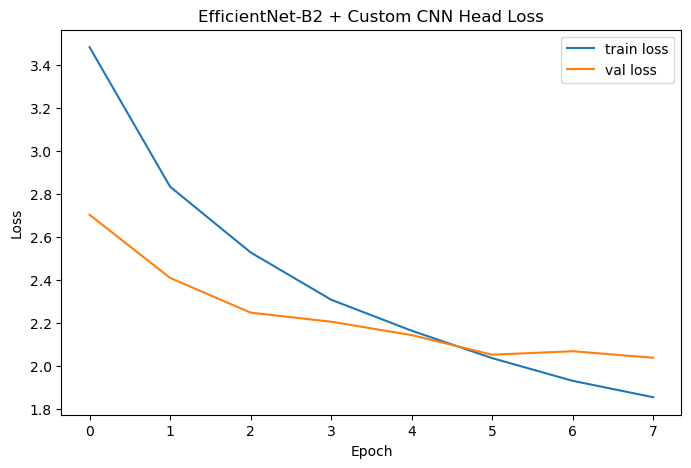

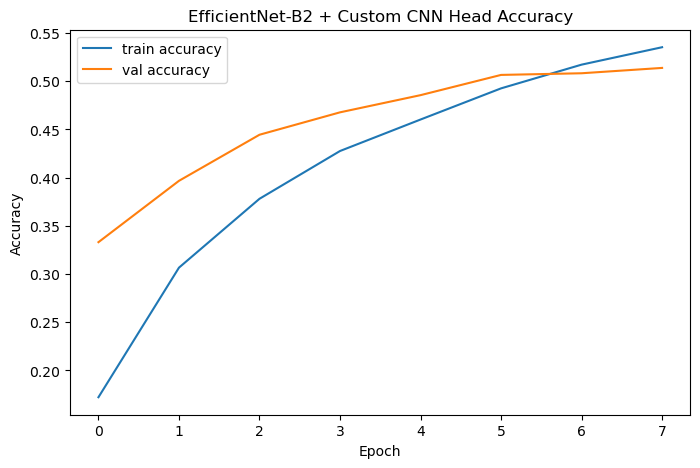

In [803]:
# Graphical representation
plt.figure(figsize=(8,5))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B2 + Custom CNN Head Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["train_acc"], label="train accuracy")
plt.plot(history["val_acc"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNet-B2 + Custom CNN Head Accuracy")
plt.legend()
plt.show()

In [804]:
import torch
from tqdm.auto import tqdm

def evaluate_topk(model, loader, device, k=5):
    model.eval()

    top1_correct = 0
    topk_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating Top-1 / Top-5", leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            # Top-1 predictions
            _, pred_top1 = torch.max(outputs, dim=1)
            top1_correct += (pred_top1 == labels).sum().item()

            # Top-k predictions
            _, pred_topk = torch.topk(outputs, k=k, dim=1)

            # Check if true label appears in top-k predictions
            labels_expanded = labels.view(-1, 1)
            topk_correct += (pred_topk == labels_expanded).any(dim=1).sum().item()

            total += labels.size(0)

    top1_acc = top1_correct / total
    topk_acc = topk_correct / total

    return top1_acc, topk_acc

In [805]:
top1_acc, top5_acc = evaluate_topk(model, test_loader, device, k=5)

print(f"Top-1 Accuracy: {top1_acc:.4f}")
print(f"Top-5 Accuracy: {top5_acc:.4f}")

Evaluating Top-1 / Top-5:   0%|          | 0/3157 [00:00<?, ?it/s]

Top-1 Accuracy: 0.7690
Top-5 Accuracy: 0.9372


In [806]:
#part c 

In [ ]:
#Self organising maps

In [807]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from minisom import MiniSom
from sklearn.preprocessing import StandardScaler
from collections import defaultdict, Counter

In [808]:
def extract_som_features(model, loader, device, max_samples=3000):
    model.eval()

    all_features = []
    all_labels = []
    count = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Extracting SOM features"):
            images = images.to(device)

            # Use existing model parts directly
            x = model.features(images)
            x = model.custom_conv(x)

            # Manual pooling here (no model change needed)
            x = torch.nn.functional.adaptive_avg_pool2d(x, (1, 1))
            x = torch.flatten(x, 1)

            all_features.append(x.cpu().numpy())
            all_labels.append(labels.numpy())

            count += images.size(0)
            if max_samples is not None and count >= max_samples:
                break

    all_features = np.concatenate(all_features, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    if max_samples is not None:
        all_features = all_features[:max_samples]
        all_labels = all_labels[:max_samples]

    return all_features, all_labels

In [848]:

# Extracting features

features, labels = extract_som_features(
    model=model,
    loader=test_loader,     
    device=device,
    max_samples=5000
)

print("Feature shape:", features.shape)   
print("Labels shape:", labels.shape)

Extracting SOM features:   0%|          | 0/3157 [00:00<?, ?it/s]

Feature shape: (5000, 256)
Labels shape: (5000,)


In [849]:

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [850]:
som_x = 15
som_y = 15

som = MiniSom(
    x=som_x,
    y=som_y,
    input_len=features_scaled.shape[1],  # 256
    sigma=1.0,
    learning_rate=0.5,
    random_seed=42
)

som.random_weights_init(features_scaled)
som.train_random(features_scaled, num_iteration=5000)

print("SOM training complete")

SOM training complete


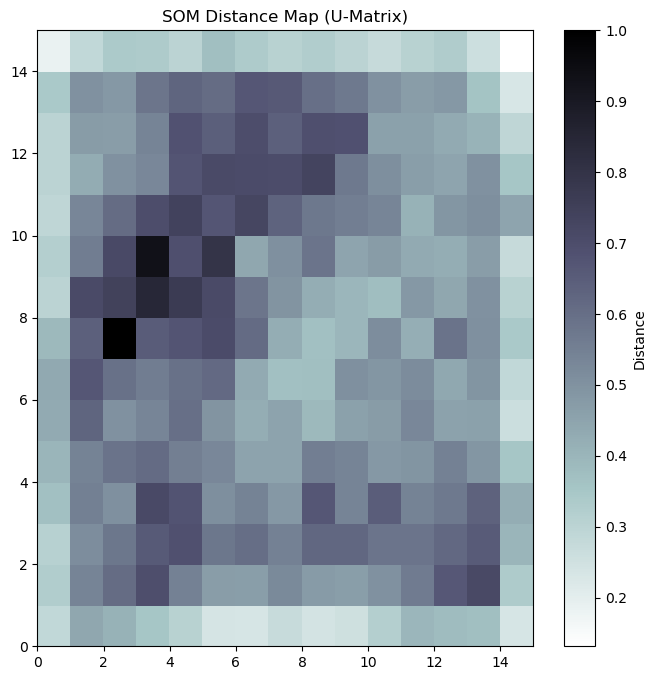

In [851]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.title("SOM Distance Map (U-Matrix)")
plt.pcolor(som.distance_map().T, cmap="bone_r")
plt.colorbar(label="Distance")
plt.show()

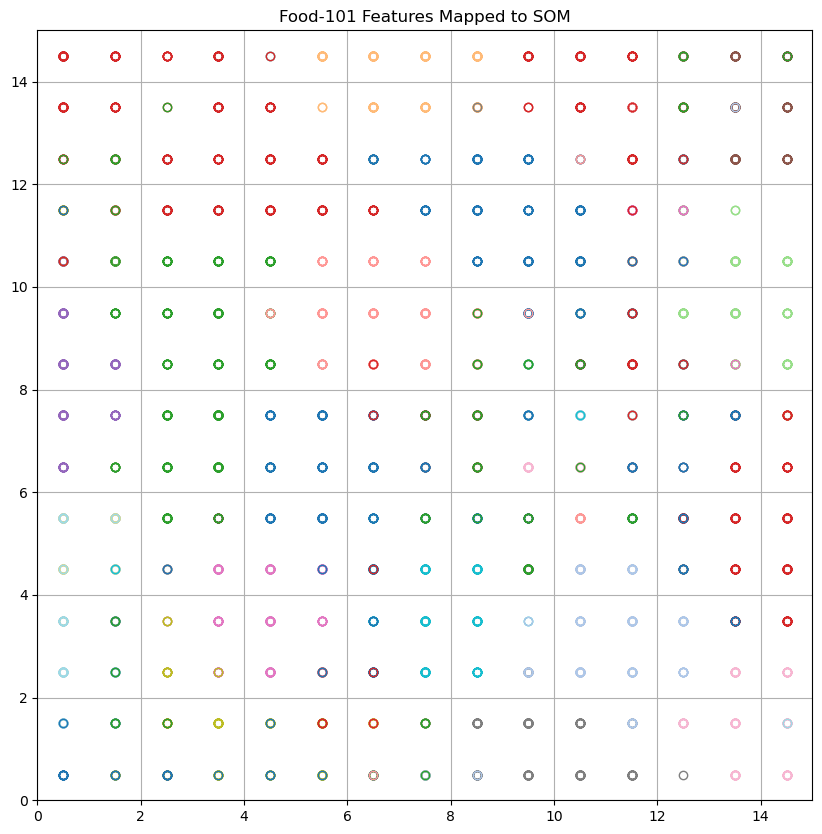

In [852]:
plt.figure(figsize=(10, 10))
plt.title("Food-101 Features Mapped to SOM")

for i, x in enumerate(features_scaled):
    w = som.winner(x)
    plt.plot(
        w[0] + 0.5,
        w[1] + 0.5,
        'o',
        markerfacecolor='None',
        markeredgecolor=plt.cm.tab20(labels[i] % 20),
        markersize=6,
        markeredgewidth=1
    )

plt.xlim([0, som_x])
plt.ylim([0, som_y])
plt.grid()
plt.show()

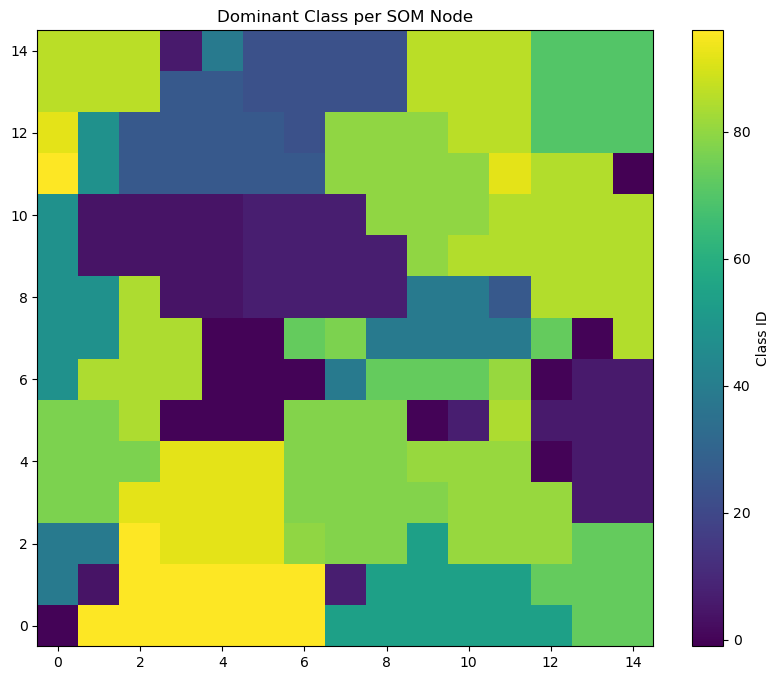

In [853]:
from collections import defaultdict, Counter

node_class_map = defaultdict(list)

for x, label in zip(features_scaled, labels):
    winner = som.winner(x)
    node_class_map[winner].append(label)

dominant_map = np.full((som_x, som_y), -1)

for node, class_list in node_class_map.items():
    dominant_class = Counter(class_list).most_common(1)[0][0]
    dominant_map[node[0], node[1]] = dominant_class

plt.figure(figsize=(10, 8))
plt.title("Dominant Class per SOM Node")
plt.imshow(dominant_map.T, origin='lower')
plt.colorbar(label='Class ID')
plt.show()

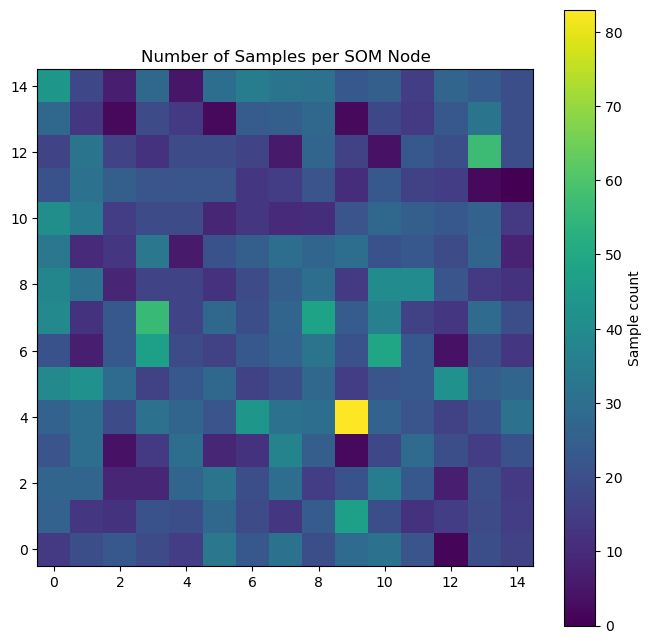

In [854]:
node_counts = np.zeros((som_x, som_y), dtype=int)

for x in features_scaled:
    w = som.winner(x)
    node_counts[w[0], w[1]] += 1

plt.figure(figsize=(8, 8))
plt.title("Number of Samples per SOM Node")
plt.imshow(node_counts.T, origin='lower', cmap='viridis')
plt.colorbar(label='Sample count')
plt.show()